# Hotel Booking Cancellation — Statistical Modeling & Hypothesis Testing

This notebook investigates **why hotel bookings get cancelled** and builds a model to predict cancellations using logistic regression.

**Dataset:** `hotel_bookings_cleaned.csv` — a cleaned dataset of hotel reservations, where the target column `is_canceled` indicates whether a booking was cancelled (`1`) or not (`0`).

**What this notebook does, step by step:**
1. Load and explore the dataset
2. Select relevant features and check them for issues (missing values, multicollinearity)
3. Split the data into training and test sets
4. Train a Logistic Regression model to predict cancellations
5. Evaluate the model's performance (accuracy, confusion matrix, classification report, ROC-AUC)
6. Perform a **formal statistical hypothesis test** on the model's coefficients to check whether the selected features have a statistically significant effect on cancellation probability

> **Note for beginners:** Logistic Regression is a classification algorithm used when the target variable is binary (here, cancelled vs. not cancelled). Unlike linear regression, it predicts the *probability* that an observation belongs to a class.

## 1. Import Required Libraries

We start by importing the libraries needed for data handling (`pandas`, `numpy`), visualization (`matplotlib`), building and splitting the model (`scikit-learn`), and running the formal statistical hypothesis test (`statsmodels`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import statsmodels.api as sm

## 2. Load the Dataset

We read the cleaned hotel bookings data into a pandas DataFrame so we can start exploring it.

In [2]:
df = pd.read_csv("hotel_bookings_cleaned.csv")

## 3. Explore the Data

Before modeling, it's good practice to get a quick feel for the dataset:
- `df.head()` — preview the first few rows and see what the columns look like
- `df.shape` — check how many rows (bookings) and columns (features) we have
- `df.info()` — check data types and spot any obvious missing values across the dataset

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_guests,total_nights,is_family,booking_status
0,Resort Hotel,0,296,2015,July,27,1,0,0.0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2,0.0,0,Not Cancelled
1,Resort Hotel,0,296,2015,July,27,1,0,0.0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,2,0.0,0,Not Cancelled
2,Resort Hotel,0,7,2015,July,27,1,0,1.0,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0,Not Cancelled
3,Resort Hotel,0,13,2015,July,27,1,0,1.0,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1,1.0,0,Not Cancelled
4,Resort Hotel,0,14,2015,July,27,1,0,2.0,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2,2.0,0,Not Cancelled


In [5]:
df.shape

(87203, 36)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87203 entries, 0 to 87202
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87203 non-null  object 
 1   is_canceled                     87203 non-null  int64  
 2   lead_time                       87203 non-null  int64  
 3   arrival_date_year               87203 non-null  int64  
 4   arrival_date_month              87203 non-null  object 
 5   arrival_date_week_number        87203 non-null  int64  
 6   arrival_date_day_of_month       87203 non-null  int64  
 7   stays_in_weekend_nights         87203 non-null  int64  
 8   stays_in_week_nights            87203 non-null  float64
 9   adults                          87203 non-null  int64  
 10  children                        87203 non-null  int64  
 11  babies                          87203 non-null  int64  
 12  meal                            

## 4. Define Features (X) and Target (y)

Here we choose the columns that will be used to predict cancellations (the **features**, `X`) and the column we're trying to predict (the **target**, `y`).

**Target variable:**
- `is_canceled` — 1 if the booking was cancelled, 0 if it was not

**Selected features:**
- `lead_time` — days between booking date and arrival date
- `adr` — average daily rate (price paid per night)
- `total_guests` — total number of guests on the booking
- `total_nights` — total nights stayed (weekday + weekend)
- `previous_cancellations` — number of previous bookings that were cancelled by the customer
- `booking_changes` — number of changes made to the booking after it was created
- `days_in_waiting_list` — number of days the booking was on a waiting list before confirmation

These were chosen because they capture booking behavior (how far in advance, how much it costs, how the guest has behaved before) that could plausibly influence whether a guest cancels.

In [8]:
features = [
    "lead_time",
    "adr",
    "total_guests",
    "total_nights",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list"
]

X = df[features]
y = df["is_canceled"]

## 5. Check for Missing Values

Logistic Regression cannot handle missing data, so we check each selected feature for null (missing) values before proceeding.

In [9]:
X.isnull().sum()

lead_time                 0
adr                       0
total_guests              0
total_nights              0
previous_cancellations    0
booking_changes           0
days_in_waiting_list      0
dtype: int64

## 6. Check Multicollinearity (VIF)

**Multicollinearity** happens when two or more features are highly correlated with each other. This can make it hard to interpret a regression model's coefficients reliably, since it becomes difficult to tell which feature is really driving the effect.

We measure this using the **Variance Inflation Factor (VIF)** for each feature:
- **VIF ≈ 1** → little to no correlation with other features
- **VIF between 1–5** → moderate correlation, generally acceptable
- **VIF > 10** → high correlation, may be worth investigating or removing the feature

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Features"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
print(vif)

                 Features       VIF
0               lead_time  2.299307
1                     adr  5.783386
2            total_guests  6.653444
3            total_nights  3.350506
4  previous_cancellations  1.004473
5         booking_changes  1.143158
6    days_in_waiting_list  1.025760


## 7. Split Data into Training and Test Sets

We split the data into a **training set** (80%) used to fit the model, and a **test set** (20%) held back to evaluate how well the model generalizes to unseen data. `random_state=42` ensures the split is reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.20,
    random_state=42
)

## 8. Build the Logistic Regression Model (scikit-learn)

We train a Logistic Regression classifier on the training data. This model will learn the relationship between our features and the probability of a booking being cancelled. `max_iter=1000` gives the optimizer enough iterations to converge.

In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 9. Generate Predictions on Test Data

Using the trained model, we generate two things on the unseen test set:
- `y_pred` — the predicted class (0 = not cancelled, 1 = cancelled)
- `y_prob` — the predicted *probability* of cancellation, which we'll use later for the ROC curve

In [13]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## 10. Evaluate Model Accuracy

**Accuracy** is the simplest evaluation metric — the percentage of test bookings the model classified correctly. It's a useful starting point, but on its own it doesn't tell us whether the model is better at catching cancellations vs. non-cancellations, which is why we also look at the confusion matrix and classification report next.

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 0.7279972478642279


## 11. Confusion Matrix

A **confusion matrix** breaks predictions down into four categories: correctly predicted non-cancellations, correctly predicted cancellations, and the two types of mistakes (false positives and false negatives). It gives a much fuller picture of model performance than accuracy alone.

In [16]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12184   432]
 [ 4312   513]]


Let's visualize the same confusion matrix as a heatmap, which is often easier to read at a glance than a raw table of numbers.

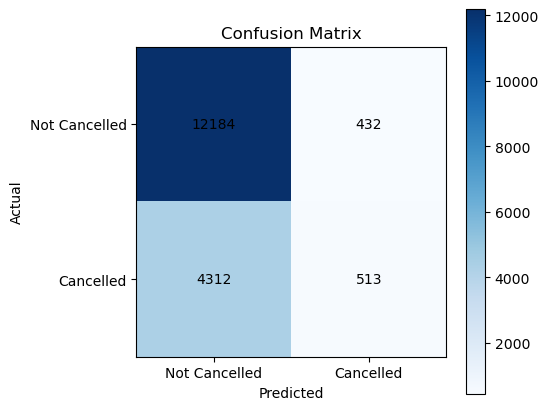

In [18]:
plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks([0,1], ["Not Cancelled", "Cancelled"])
plt.yticks([0,1], ["Not Cancelled", "Cancelled"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j], ha="center", va="center", color="black")

plt.title("Confusion Matrix")
plt.show()

## 12. Classification Report

The classification report gives per-class metrics that dig deeper than accuracy:
- **Precision** — of all bookings predicted as cancelled, how many actually were?
- **Recall** — of all bookings that were actually cancelled, how many did the model catch?
- **F1-score** — the balance between precision and recall

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.97      0.84     12616
           1       0.54      0.11      0.18      4825

    accuracy                           0.73     17441
   macro avg       0.64      0.54      0.51     17441
weighted avg       0.68      0.73      0.65     17441



## 13. ROC Curve

The **ROC (Receiver Operating Characteristic) curve** shows the trade-off between the true positive rate and false positive rate at different probability thresholds. A curve that hugs the top-left corner indicates a better-performing model; the dashed diagonal line represents random guessing.

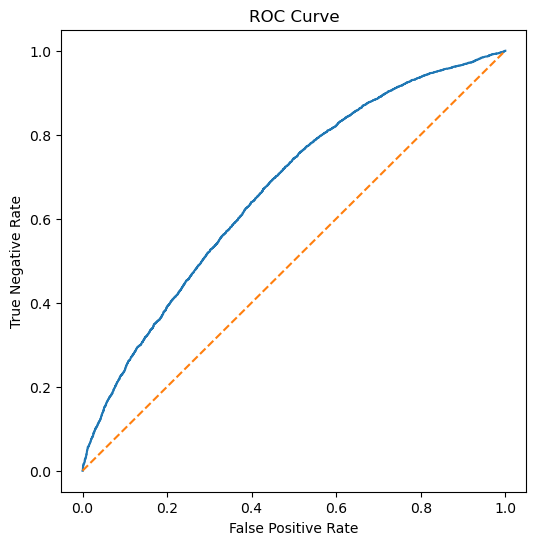

In [21]:
fpr, tnr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tnr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Negative Rate")
plt.title("ROC Curve")
plt.show()

The **ROC-AUC score** condenses the entire ROC curve into a single number between 0 and 1 — the probability that the model ranks a randomly chosen cancelled booking higher than a randomly chosen non-cancelled one. A score of 0.5 means no better than random guessing, while 1.0 means perfect separation.

In [22]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc}")

ROC-AUC Score: 0.6679771964870662


## 14. Formal Hypothesis Testing with Logistic Regression (statsmodels)

While scikit-learn is great for building predictive models, `statsmodels` gives us detailed statistical output — including **p-values** — needed to formally test whether each feature has a statistically significant relationship with booking cancellations.

**Hypotheses for each feature's coefficient:**
- **Null Hypothesis (H₀):** The feature has no effect on the log-odds of cancellation (its coefficient = 0)
- **Alternative Hypothesis (H₁):** The feature has a statistically significant effect on the log-odds of cancellation (its coefficient ≠ 0)

We add a constant term (intercept) to the features and fit a Logit model. For each feature, a **p-value < 0.05** means we reject the null hypothesis for that feature — i.e., there's strong evidence it genuinely affects cancellation likelihood.

In [23]:
X_const = sm.add_constant(X)
logit = sm.Logit(y, X_const)
result = logit.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.552345
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                87203
Model:                          Logit   Df Residuals:                    87195
Method:                           MLE   Df Model:                            7
Date:                Sun, 02 Aug 2026   Pseudo R-squ.:                 0.06139
Time:                        01:17:04   Log-Likelihood:                -48166.
converged:                       True   LL-Null:                       -51316.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.2002      0.028    -79.692      0.000      -2.254      

## 15. Hypothesis Test Conclusion

Here we check whether *any* of the features have a p-value below the 0.05 significance threshold. If at least one does, we reject the overall null hypothesis, concluding that our set of features collectively has a statistically significant relationship with booking cancellations.

In [24]:
if (result.pvalues < 0.05).any():
    print("Reject the Null Hypothesis")
else: 
    print("Fail to reject the Null Hypothesis")

Reject the Null Hypothesis


## 16. Summary & Conclusion

- We built a **Logistic Regression** model to predict hotel booking cancellations using seven behavioral and booking-related features.
- The model's performance was evaluated using **accuracy, a confusion matrix, a classification report, and the ROC-AUC score**.
- A formal statistical test (via `statsmodels`) showed that the selected features are **statistically significant predictors** of cancellation, since one or more p-values fell below the 0.05 threshold — leading us to **reject the null hypothesis**.
- In practical terms, this suggests factors like lead time, price (ADR), guest/night counts, prior cancellation history, booking changes, and waiting-list days all carry meaningful information about whether a guest is likely to cancel — insights a hotel could use for targeted retention strategies (e.g., confirmation reminders for high lead-time bookings).